# A_4_1 — Lexical baseline (TF-IDF and K-means)

**Input:** `Results/Delay_reason_only*.xlsx`, `Data/Project non submitted-non compliant_2020_2026.xlsx`
**Output:** `Images/Kmeans_delay.png`, `Images/Kmeans_rescheduled.png` (SI Figs 1–2)

Vectorises the statements and inspects the inertia curve across K. The curve
declines smoothly without an elbow, consistent with the continuous thematic
overlap of promoter wording. K-means is therefore used only to orient the
interpretation, not to fix the number of final categories.


In [1]:
import pandas as pd
import nltk
import matplotlib.pyplot as plt
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from nltk.corpus import stopwords
import os

In [2]:
df = pd.read_excel("Results/Delay_reason_onlyDelayed.xlsx")

In [3]:
print(f"Before cleaning: {len(df)}")
df.dropna(subset=['Inv_Progress Driver'], inplace=True)
df = df[df['Inv_Progress Driver'].astype(str).str.strip() != '']
print(f"Rows without nan: {len(df)}")

Before cleaning: 484
Rows without nan: 476


In [4]:
frasi = df['Inv_Progress Driver'].astype(str).tolist()
stopwords_en = stopwords.words('english')

In [5]:
vectorizer = TfidfVectorizer(
    stop_words=stopwords_en,
    lowercase=True,          
    max_df=0.85,             
    min_df=2,                
    ngram_range=(1, 2)       
)

X = vectorizer.fit_transform(frasi)

In [6]:
os.environ["LOKY_MAX_CPU_COUNT"] = "4"

K_range = range(2, 20)
distortions = []

for k in K_range:
    kmeans_model = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans_model.fit(X)
    distortions.append(kmeans_model.inertia_)

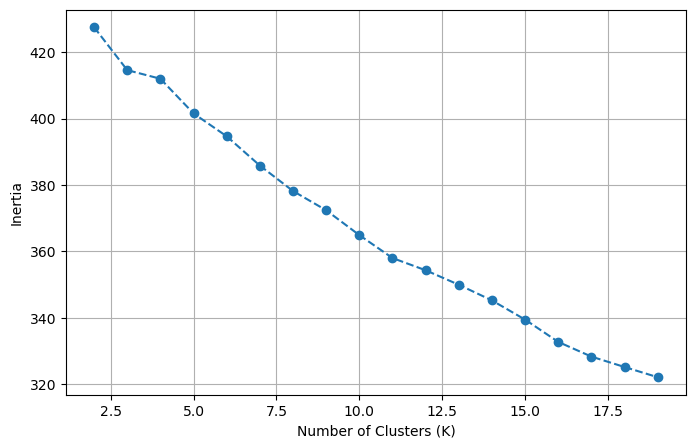

In [7]:
# Choice of K
plt.figure(figsize=(8, 5))
plt.plot(K_range, distortions, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.grid(True)

plt.savefig("Images/Kmeans_delay.png", dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

In [8]:
optimal_k = 11


In [9]:
final_kmeans = KMeans(n_clusters=optimal_k, n_init=10, random_state=42)
final_kmeans.fit(X)
labels = final_kmeans.labels_

df = pd.DataFrame({'Sentence': frasi, 'KMeans': labels})

In [10]:
order_centroids = final_kmeans.cluster_centers_.argsort()[:, ::-1]

terms = vectorizer.get_feature_names_out()

for i in range(optimal_k):
    print(f"\nCluster {i} (Total Sentences: {len(df[df['KMeans'] == i])}):")
    top_n_words = [terms[ind] for ind in order_centroids[i, :10]]
    print(f"Key Terms: {', '.join(top_n_words)}")
    print("Example sentences in the cluster:")
    for _, row in df[df['KMeans'] == i].head(3).iterrows():
        print(f" - {row['Sentence']}")


Cluster 0 (Total Sentences: 13):
Key Terms: renewable energy, awaiting international, international, international contracts, contracts renewable, contracts, awaiting, renewable, energy, due events
Example sentences in the cluster:
 - Awaiting international contracts for renewable energy
 - Awaiting international contracts for renewable energy
 - Awaiting international contracts for renewable energy

Cluster 1 (Total Sentences: 45):
Key Terms: long permitting, due long, long, delay due, permitting process, process, delay, permitting, due, complex long
Example sentences in the cluster:
 - Delay due to long permitting process
 - delay due to long permitting process
 - delay due to long permitting process

Cluster 2 (Total Sentences: 40):
Key Terms: investment, explanation, problems, 496, investment 496, affected explanation, explanation investment, delay investment, investment affected, affected
Example sentences in the cluster:
 - Although the investment is already under construction s

In [11]:
df.to_excel("Results/Cluster_KMeans_delay.xlsx")

### Rescheduling 

In [12]:
df = pd.read_excel("Results/Delay_reason_onlyRescheduled.xlsx")

In [13]:
print(f"Before cleaning: {len(df)}")

df.dropna(subset=['Inv_Progress Driver'], inplace=True)

df = df[df['Inv_Progress Driver'].astype(str).str.strip() != '']

print(f"Rows without nan: {len(df)}")

Before cleaning: 317
Rows without nan: 213


In [14]:
frasi = df['Inv_Progress Driver'].astype(str).tolist()
stopwords_en = stopwords.words('english')

In [15]:
vectorizer = TfidfVectorizer(
    stop_words=stopwords_en, 
    lowercase=True,          
    max_df=0.85,             
    min_df=2,                
    ngram_range=(1, 2)      
)

X = vectorizer.fit_transform(frasi)


In [16]:
K_range = range(2, 20)
distortions = []

for k in K_range:
    kmeans_model = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans_model.fit(X)
    distortions.append(kmeans_model.inertia_)

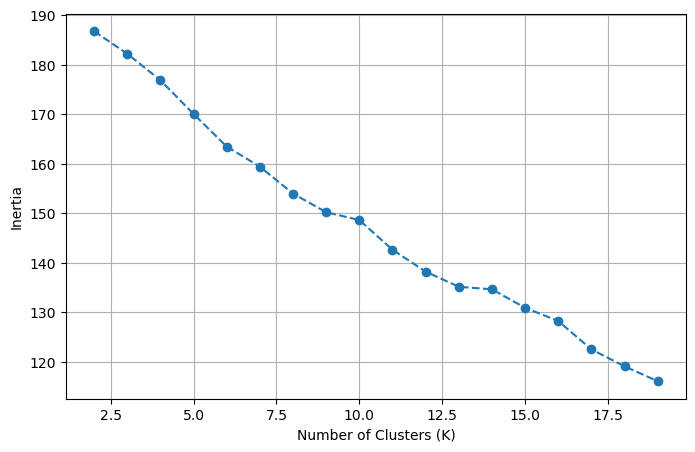

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(K_range, distortions, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.grid(True)
plt.savefig("Images/Kmeans_rescheduled.png", dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

In [18]:
optimal_k = 9


In [19]:
final_kmeans = KMeans(n_clusters=optimal_k, n_init=10, random_state=42)
final_kmeans.fit(X)
labels = final_kmeans.labels_

df = pd.DataFrame({'Sentence': frasi, 'KMeans': labels})

In [20]:
order_centroids = final_kmeans.cluster_centers_.argsort()[:, ::-1]
terms = vectorizer.get_feature_names_out()

for i in range(optimal_k):
    print(f"\nCluster {i} (Total Sentences: {len(df[df['KMeans'] == i])}):")
    top_n_words = [terms[ind] for ind in order_centroids[i, :10]]
    print(f"Key Terms: {', '.join(top_n_words)}")
    
    print("Example sentences in the cluster:")
    for _, row in df[df['KMeans'] == i].head(3).iterrows():
        print(f" - {row['Sentence']}")


Cluster 0 (Total Sentences: 13):
Key Terms: project, project moved, synchronization project, prioritisation, project investments, prioritisation synchronization, investments related, forward prioritisation, forward, synchronization
Example sentences in the cluster:
 - The project have been moved forward because of prioritisation of the Synchronization project to which all those investments are related to
 - The project have been moved forward because of prioritisation of the Synchronization project to which all those investments are related to
 - The project have been moved forward because of prioritisation of the Synchronization project to which all those investments are related to

Cluster 1 (Total Sentences: 13):
Key Terms: study, study expected, expected launched, launched, feasibility study, feasibility, expected, study finalized, reference study, process procurement
Example sentences in the cluster:
 - Feasibility study is expected to be launched.
 - Feasibility study is expecte

In [21]:
df.to_excel("Results/Cluster_Kmeans_Rescheduled.xlsx")

### Cancelled

In [22]:
df = pd.read_excel("Data/Project non submitted-non compliant_2020_2026.xlsx")

In [23]:
print(f"Before cleaning: {len(df)}")
df.dropna(subset=['Reason_of_cancellation'], inplace=True)
df = df[df['Reason_of_cancellation'].astype(str).str.strip() != '']
print(f"Rows without nan: {len(df)}")

Before cleaning: 51
Rows without nan: 51


In [24]:
frasi = df['Reason_of_cancellation'].astype(str).tolist()
stopwords_en = stopwords.words('english')

In [25]:
vectorizer = TfidfVectorizer(
    stop_words=stopwords_en, 
    lowercase=True,          
    max_df=0.85,             
    min_df=2,                
    ngram_range=(1, 2)       
)

X = vectorizer.fit_transform(frasi)

In [26]:
K_range = range(2, 20)
distortions = []

for k in K_range:
    kmeans_model = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans_model.fit(X)
    distortions.append(kmeans_model.inertia_)

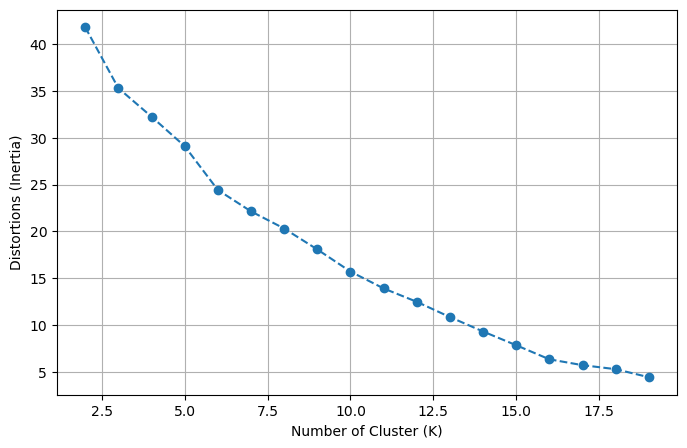

In [27]:
plt.figure(figsize=(8, 5))
plt.plot(K_range, distortions, marker='o', linestyle='--')
plt.xlabel('Number of Cluster (K)')
plt.ylabel('Distortions (Inertia)')
plt.grid(True)
plt.show()

In [28]:
optimal_k = 6


In [29]:
final_kmeans = KMeans(n_clusters=optimal_k, n_init=10, random_state=42)
final_kmeans.fit(X)
labels = final_kmeans.labels_

df = pd.DataFrame({'Sentence': frasi, 'KMeans': labels})

In [30]:
order_centroids = final_kmeans.cluster_centers_.argsort()[:, ::-1]
terms = vectorizer.get_feature_names_out()

for i in range(optimal_k):
    print(f"\nCluster {i} (Total Sentences: {len(df[df['KMeans'] == i])}):")
    top_n_words = [terms[ind] for ind in order_centroids[i, :10]]
    print(f"Key Terms: {', '.join(top_n_words)}")
    print("Example sentences in the cluster:")
    for _, row in df[df['KMeans'] == i].head(3).iterrows():
        print(f" - {row['Sentence']}")


Cluster 0 (Total Sentences: 4):
Key Terms: compliance, criteria, inclusion, administrative, inclusion tyndp, mandatory inclusion, criteria mandatory, criteria compliance, administrative criteria, prove compliance
Example sentences in the cluster:
 - The project did not prove compliance with any of the additional administrative criteria e) to k). Compliance with at least one of these criteria is mandatory for inclusion in TYNDP.
 - The project did not prove compliance with any of the additional administrative criteria e) to k). Compliance with at least one of these criteria is mandatory for inclusion in TYNDP.
 - The project did not prove compliance with any of the additional administrative criteria e) to k). Compliance with at least one of these criteria is mandatory for inclusion in TYNDP.

Cluster 1 (Total Sentences: 4):
Key Terms: cancelled, criteria, de bruxelles, de, currently, current assumptions, current, cross border, cross, criteria mandatory
Example sentences in the cluster:

In [31]:
df.to_excel("Results/Cluster_Kmeans_Cancelled.xlsx")